# Atividade 1

Utilizando o gráfico de Elevação X Temperatura (Figura 3.3 - Fox 
et al. (2018), gráfico apresentado no slide de aula, obter um modelo que
 descreva como a pressão varia com a elevação, nos seguintes casos:

 ![Gráfico_temperatura_elevação](Grafico_Temperatura_elevacao.png)

## Casos

### Bibliotecas, Dados e Constantes

#### Bibliotecas utilizadas

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Abertura de CSV

In [16]:
df = pd.read_excel("Dados_Temperatura.xlsx")

temperatura = df['Temperatura (K)']
altura = df['Elevação (km)']

print(df)

    Elevação (km)  Temperatura (K)
0               0       301.301604
1               1       278.240837
2               2       277.521503
3               3       260.259064
4               4       275.382433
5               5       252.070363
6               6       259.201939
7               7       248.331449
8               8       227.136951
9               9       226.493083
10             10       217.689877
11             11       216.650000


#### Declarando constantes

In [17]:
R = 287.058 # J/Kg*K
T = -56.5 + 273.15 # K -> Será utilizada no caso 1
G = 9.81 # m/s²
p_0 = 101325 # Pa

### Caso 2: Temperatura variante

Para o intervalo de 0 até 11,0 km, onde a temperatura varia, utilizando os 
dados de temperatura em anexo, ajustar uma função T(E) utilizando o 
cálculo matricial do Método dos Mínimos Quadrados (MMQ, OLS em inglês). 
Após a obtenção da função de T(E), obter a função p(E), plotar o gráfico
 de Pressão X Elevação (pressão na ordenada).

$T(E) = aE + b$

$a$: Variação da temperatura

$b$: Temperatura no nível do mar

Será resolvido pelo cálculo das matrizes

$[Y] = [X] \cdot [\beta]$

$Y$: valores da temperatura

$X$: valores da elevação

$\beta$: matriz com coeficientes a,b

Nosso objetivo é achar $\beta$, então podemos fazer $[\beta] = [X]^{-1} * [Y]$

In [18]:
Y = temperatura.to_numpy().reshape(-1,1)
print('Matriz Y')
print(Y)

print("\n------------------------------")

X = altura.to_numpy().reshape(-1,1)
coluna_1 = np.ones((Y.shape[0], 1))
X = np.hstack((coluna_1, X))

print('Matrix X')
print(X)

print("\n------------------------------")

# Pseudo inversa de Penrose
def penrose(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

beta = penrose(X, Y)

a = beta[1] # Inclinação: Variação da temperatura
b = beta[0] # Intecepto: Temperatura no nível do mar

print(f"Coeficientes: a = {a}, b = {b}")

Matriz Y
[[301.30160387]
 [278.24083745]
 [277.52150309]
 [260.25906395]
 [275.38243282]
 [252.07036337]
 [259.20193877]
 [248.33144933]
 [227.13695085]
 [226.49308318]
 [217.68987674]
 [216.65      ]]

------------------------------
Matrix X
[[ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]
 [ 1.  4.]
 [ 1.  5.]
 [ 1.  6.]
 [ 1.  7.]
 [ 1.  8.]
 [ 1.  9.]
 [ 1. 10.]
 [ 1. 11.]]

------------------------------
Coeficientes: a = [-7.24810199], b = [293.22115289]


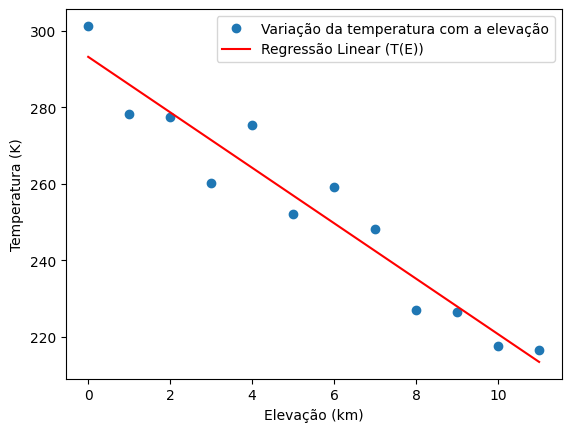

In [19]:
def t(e):
    return a*e + b

plt.plot(Y, 'o', label='Variação da temperatura com a elevação')
plt.plot(altura, t(altura), 'r', label='Regressão Linear (T(E))')
plt.xlabel("Elevação (km)")
plt.ylabel("Temperatura (K)")
plt.legend()
plt.show()




$$ \frac{dp}{dz} = -ρg $$

Onde:

$$
\begin{aligned}
ρ = \frac{p}{R T}
\end{aligned}
$$

Então:

$$ \frac{dp}{dz} = \frac{-pg}{RT} $$
$$\int^{p}_{p_0} \frac{dP}{p} = -\frac{g}{R} \int^{z}_{z_0} \frac{dz}{T}$$
$$\int^{p}_{p_0} \frac{dP}{p}  = -\frac{g}{R} \int^{z}_{z_0} \frac{dz}{(az+b)}$$

$$\frac{ln(p)}{ln(p_0)} = -\frac{g}{aR} \cdot \ln(\frac{az+b}{b}) $$

$$ {ln(p)} = {ln(p_o)} \cdot -\frac{g}{aR}\cdot \ln(\frac{az+b}{b}) $$

$$ {(e)} \cdot  {ln(p)} = {ln(p_o)} \cdot -\frac{g}{aR}\cdot \ln(\frac{az+b}{b}) \cdot {(e)}$$

$$ {p} = {p_o} \cdot {(e)^{-\frac{g}{aR} \cdot \ln(\frac{az+b}{b}) }}$$

$$
p = p_o \cdot e^{\left( \ln(\frac{az+b}{b}) \right)^{-\frac{g}{aR}}} $$

$$
p = p_o \cdot \left( \frac{az+b}{b} \right)^{-\frac{g}{aR}}$$

**Portanto a função P(E) é:**

$$
p(E) = p_o \cdot \left( \frac{T(E)}{(b)} \right)^{-\frac{g}{aR}}$$

In [20]:
def p(e):
    T = t(e)
    e = e * (10**3)
    a_m = a / (10**3)
    return p_0 * (T/b) ** (-(G / (R * a_m)))

p_11 = p(11)

print(f"Pressão em 11km: {p_11[0]:.2f} Pa")

Pressão em 11km: 22695.27 Pa


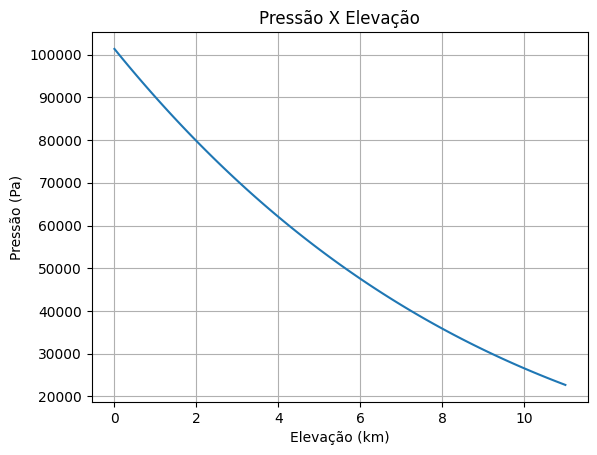

In [21]:
# Altitude em km
altitude = np.linspace(0, 11, 100)  # 100 pontos na plotagem

# Calculando a pressão
pressao = p(altitude)

# Plotagem da função de P(E)
plt.plot(altitude, pressao)
plt.xlabel('Elevação (km)')
plt.ylabel('Pressão (Pa)')
plt.title('Pressão X Elevação')
plt.grid(True)
plt.show()

### Caso 1: Temperatura Constante

Para o intervalo de 11,0 até 20,1 km, onde a temperatura permanece 
constante (-56,5 C), obter um modelo que represente como a pressão varia
 com a elevação. Após obtenção da função p(E), sendo E a elevação, 
plotar o gráfico de Pressão X Elevação (pressão na ordenada);

Neste caso, a temperatura permanece constante facilitando o cálculo:

$$ \frac{dp}{dz} = -ρg $$

Onde:

$$
\begin{aligned}
ρ = \frac{p}{R T}
\end{aligned}
$$

Então:

$$ \frac{dp}{dz} = \frac{-pg}{RT} $$
$$\int^{p}_{p_0} \frac{dP}{p} = -\frac{g}{RT} \int^{z}_{z_0} dz$$

$$\ln(\frac{p}{p_0}) = -\frac{g}{RT} \cdot (z - z_0) $$

$$ {(e)} \cdot  \ln(\frac{p}{p_0}) = -\frac{g}{RT} \cdot (z - z_0) \cdot {(e)}$$

$$ \frac{p}{p_0} = {(e)^{-\frac{g}{RT} \cdot (z - z_0) }} $$

$$ {p} = {p_o} \cdot {(e)^{-\frac{g}{RT} \cdot (z - z_0) }}$$

**Portanto a função P é:**

$$ {p} = {p_o} \cdot {(e)^{-\frac{g}{RT} \cdot (\Delta{z}) }}$$

Para obter o valor correspondente da pressão em 11km, neste caso o $p_0$, usaremos a equação encontrada no Caso 2:

$$
p(E) = p_o \cdot \left( \frac{T(E)}{(b)} \right)^{-\frac{g}{aR}}
$$


In [22]:
def p(e):
    e_m = e * (10**3) # Convertendo para metros
    a_m = a / (10**3) # Convertendo para K/m
    return p_0 * ((a_m*e_m+b)/b)**(-(G/(R*a_m)))

p_11 = p(11)

print(f"Pressão em 11km: {p_11[0]:.5f} Pa")

Pressão em 11km: 22695.26669 Pa


Para fins mais exatos, no livro Mecânica dos fluídos de Frank M. White é utilizada a seguinte equação:

$$
p = p_0 (1 - \frac{Bz}{T_0})^{\frac{g}{RB}}
$$

Onde $T_0$ é a temperatura ao nível do mar (absoluta) e B é a taxa de declínio, ambas variando de um dia para outro. No entanto, em um acordo internacional foram aceitos os seguintes valores padrão a serem aplicados de 0 até 11.000 m:

$$
T_0 = 288.16 K
$$

$$
B = 0.00650 K/m
$$

Logo, para resolver este exercicio utilizaremos os valores padrões.

In [23]:
B = 0.00650 # K/m
t_0 = 288.16 # K
# R = 287.058 # J/Kg*K
# G = 9.81 # m/s²
# p_0 = 101325 # Pa

def p_padrao(e):
    e = e * (10**3)
    return p_0 * (1 - ((B*e)/t_0))**((G/(R*B)))

p_11_padrao = p_padrao(11)

print(f"Pressão em 11km: {p_11_padrao:.5f} Pa")

Pressão em 11km: 22622.42254 Pa


In [24]:
def p_1(e, p_0, e_inicial):
    e = e * (10**3)
    delta_e = e - e_inicial
    return p_0 * (np.exp(-(G/(R*T) * (delta_e))))

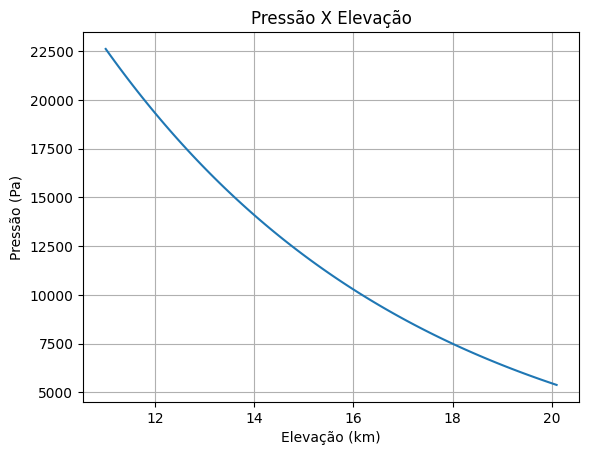

In [25]:
e_inicial = 11000

altitude = np.linspace(11.0, 20.1, 100)  # 100 pontos na plotagem

p_o_11 = p_11_padrao
pressao = p_1(altitude, p_o_11, e_inicial)

plt.plot(altitude, pressao)
plt.xlabel('Elevação (km)')
plt.ylabel('Pressão (Pa)')
plt.title('Pressão X Elevação')
plt.grid(True)
plt.show()

In [26]:
df_pressao_elevacao = pd.DataFrame({'Altitude (km)': altitude, 'Pressão (Pa)': p_1(altitude, p_o_11, e_inicial)})

df_pressao_elevacao

,Altitude (km),Pressão (Pa)
0,11.000000,22622.422542
1,11.091919,22296.779885
2,11.183838,21975.824752
3,11.275758,21659.489667
4,11.367677,21347.708126
...,...,...
95,19.732323,5705.945088
96,19.824242,5623.809803
97,19.916162,5542.856830
98,20.008081,5463.069150


### Caso 3: Plotar o gráfico de Pressão X Elevação (pressão na ordenada) de 0 a 20,1 km.

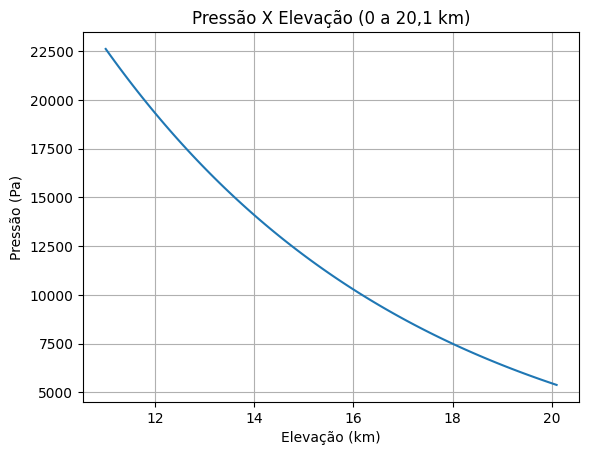

In [27]:
alt_total = df_pressao_elevacao['Altitude (km)']
pres_total = df_pressao_elevacao['Pressão (Pa)']

plt.plot(alt_total, pres_total)
plt.xlabel('Elevação (km)')
plt.ylabel('Pressão (Pa)')
plt.title('Pressão X Elevação (0 a 20,1 km)')
plt.grid(True)
plt.show()